<a href="https://colab.research.google.com/github/sanchezmicaela/Aprendizaje_Automatico/blob/main/9_proyectofinal_micaela_sanchez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nombres de integrantes del grupo:**

*   Micaela Arami Sánchez Arce



# Proyecto Final – Clasificación de Mortalidad por Melanoma

## Objetivo

Desarrollar un modelo de clasificación binaria capaz de predecir la mortalidad por melanoma a cinco años (`mort_5yr`) utilizando variables clínicas y patológicas de pacientes sometidos a cirugía por melanoma maligno.

## Etapas de un proyecto de Aprendizaje Automático

1. Definición del problema.
2. Recolección y comprensión de los datos.
3. Preparación y limpieza de los datos.
4. Análisis exploratorio.
5. Selección de variables.
6. División en conjuntos de entrenamiento y prueba.
7. Construcción y entrenamiento de modelos.
8. Optimización de hiperparámetros.
9. Evaluación del desempeño.
10. Interpretación de resultados y conclusiones.

## Descripción del conjunto de datos

El conjunto de datos utilizado corresponde a pacientes tratados por melanoma maligno en el Hospital Universitario de Odense, Dinamarca. El objetivo es analizar factores asociados a la mortalidad por melanoma a cinco años.

Las variables consideradas incluyen edad, año de intervención, espesor tumoral, presencia de ulceración y clasificación TNM derivada de la profundidad del tumor (T1–T4).

La variable objetivo es `mort_5yr`, que indica si el paciente falleció por melanoma dentro de los cinco años posteriores a la cirugía.

In [4]:
from google.colab import files

uploaded = files.upload()

Saving melanoma.csv to melanoma (1).csv


In [5]:
import pandas as pd

df = pd.read_csv("melanoma.csv")
df.head()

,time,status,sex,age,year,thickness,ulcer,sex.factor,ulcer.factor,status.factor,t_stage.factor,mort_5yr
0,10,3,1,76,1972,6.76,1,Male,Present,Died - other,T4,No
1,30,3,1,56,1968,0.65,0,Male,Absent,Died - other,T1,No
2,35,2,1,41,1977,1.34,0,Male,Absent,Alive,T2,No
3,99,3,0,71,1968,2.90,0,Female,Absent,Died - other,T3,No
4,185,1,1,52,1965,12.08,1,Male,Present,Died melanoma,T4,Yes


In [6]:
print(df.shape)
df.info()

(205, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            205 non-null    int64  
 1   status          205 non-null    int64  
 2   sex             205 non-null    int64  
 3   age             205 non-null    int64  
 4   year            205 non-null    int64  
 5   thickness       205 non-null    float64
 6   ulcer           205 non-null    int64  
 7   sex.factor      205 non-null    object 
 8   ulcer.factor    205 non-null    object 
 9   status.factor   205 non-null    object 
 10  t_stage.factor  205 non-null    object 
 11  mort_5yr        205 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 19.3+ KB


In [7]:
df.head()

,time,status,sex,age,year,thickness,ulcer,sex.factor,ulcer.factor,status.factor,t_stage.factor,mort_5yr
0,10,3,1,76,1972,6.76,1,Male,Present,Died - other,T4,No
1,30,3,1,56,1968,0.65,0,Male,Absent,Died - other,T1,No
2,35,2,1,41,1977,1.34,0,Male,Absent,Alive,T2,No
3,99,3,0,71,1968,2.90,0,Female,Absent,Died - other,T3,No
4,185,1,1,52,1965,12.08,1,Male,Present,Died melanoma,T4,Yes


In [8]:
df.columns

Index(['time', 'status', 'sex', 'age', 'year', 'thickness', 'ulcer',
       'sex.factor', 'ulcer.factor', 'status.factor', 't_stage.factor',
       'mort_5yr'],
      dtype='object')

In [9]:
df["mort_5yr"].value_counts()

,count
mort_5yr,
No,160
Yes,45


In [10]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            205 non-null    int64  
 1   status          205 non-null    int64  
 2   sex             205 non-null    int64  
 3   age             205 non-null    int64  
 4   year            205 non-null    int64  
 5   thickness       205 non-null    float64
 6   ulcer           205 non-null    int64  
 7   sex.factor      205 non-null    object 
 8   ulcer.factor    205 non-null    object 
 9   status.factor   205 non-null    object 
 10  t_stage.factor  205 non-null    object 
 11  mort_5yr        205 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 19.3+ KB


In [11]:
# Variables predictoras y variable objetivo

X = df[['age',
        'year',
        'thickness',
        'sex.factor',
        'ulcer.factor',
        't_stage.factor']]

y = df['mort_5yr']

print("Dimensiones de X:", X.shape)
print("\nDistribución de la variable objetivo:")
print(y.value_counts())

Dimensiones de X: (205, 6)

Distribución de la variable objetivo:
mort_5yr
No     160
Yes     45
Name: count, dtype: int64


## División de los datos en entrenamiento y prueba

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)

print("\nDistribución en entrenamiento:")
print(y_train.value_counts())

print("\nDistribución en prueba:")
print(y_test.value_counts())

Dimensiones de X_train: (164, 6)
Dimensiones de X_test: (41, 6)

Distribución en entrenamiento:
mort_5yr
No     128
Yes     36
Name: count, dtype: int64

Distribución en prueba:
mort_5yr
No     32
Yes     9
Name: count, dtype: int64


## Preprocesamiento de variables

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Variables numéricas
numeric_features = [
    'age',
    'year',
    'thickness'
]

# Variables categóricas
categorical_features = [
    'sex.factor',
    'ulcer.factor',
    't_stage.factor'
]

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         categorical_features)
    ]
)

print("Preprocesamiento creado correctamente.")

Preprocesamiento creado correctamente.


## Pipeline 1: Regresión Logística

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

pipeline_lr.fit(X_train, y_train)

print("Pipeline de Regresión Logística entrenado correctamente.")

Pipeline de Regresión Logística entrenado correctamente.


In [15]:
from sklearn.metrics import accuracy_score

y_pred_lr = pipeline_lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy Regresión Logística:", round(accuracy_lr, 4))

Accuracy Regresión Logística: 0.7317


## Pipeline 2: Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline_rf.fit(X_train, y_train)

print("Pipeline Random Forest entrenado correctamente.")

Pipeline Random Forest entrenado correctamente.


In [17]:
y_pred_rf = pipeline_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", round(accuracy_rf, 4))

Accuracy Random Forest: 0.7805


## Optimización del modelo Random Forest con GridSearchCV

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 3, 5, 10],
    'classifier__min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_search_rf.best_params_)

print("\nMejor ROC-AUC promedio en validación cruzada:")
print(round(grid_search_rf.best_score_, 4))

Mejores parámetros:
{'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}

Mejor ROC-AUC promedio en validación cruzada:
0.7438


## Evaluación final del modelo optimizado

In [20]:
best_model = grid_search_rf.best_estimator_

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred_best), 4))
print("Precision:", round(precision_score(y_test, y_pred_best, pos_label="Yes"), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best, pos_label="Yes"), 4))
print("F1-score :", round(f1_score(y_test, y_pred_best, pos_label="Yes"), 4))

Accuracy : 0.7561
Precision: 0.4
Recall   : 0.2222
F1-score : 0.2857


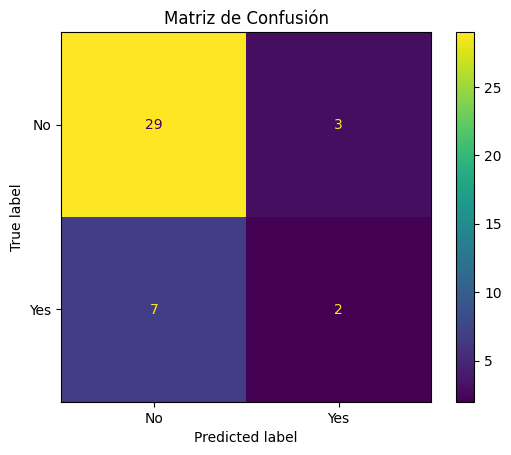

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Matriz de Confusión")
plt.show()

La matriz de confusión muestra que el modelo clasificó correctamente 29 pacientes sin mortalidad por melanoma y 2 pacientes con mortalidad. Sin embargo, se observaron 7 falsos negativos, lo que indica dificultades para detectar todos los casos positivos.

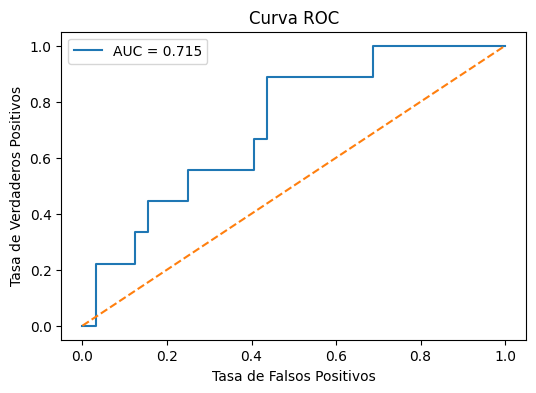

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score

y_test_bin = (y_test == "Yes").astype(int)

fpr, tpr, _ = roc_curve(y_test_bin, y_prob_best)
auc = roc_auc_score(y_test_bin, y_prob_best)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()

El valor AUC = 0,715 indica una capacidad de discriminación aceptable, superior a una clasificación aleatoria, aunque todavía existe margen para mejorar el desempeño predictivo.

## Conclusión

El presente estudio abordó la predicción de la mortalidad por melanoma a cinco años mediante técnicas de aprendizaje automático aplicadas a variables clínicas y patológicas de pacientes intervenidos quirúrgicamente. El proceso incluyó la preparación de los datos, la construcción de pipelines reproducibles, la comparación de algoritmos de clasificación y la optimización de hiperparámetros mediante validación cruzada.

La evaluación comparativa evidenció un desempeño superior del modelo Random Forest respecto a la Regresión Logística, alcanzando una exactitud de 75,61% y un área bajo la curva ROC de 0,715 sobre datos no utilizados durante el entrenamiento. Estos resultados indican una capacidad razonable para distinguir entre pacientes con y sin mortalidad asociada al melanoma en el horizonte temporal considerado.

No obstante, el análisis de la matriz de confusión y de las métricas de recuperación muestra que la detección de casos positivos continúa siendo un desafío. El modelo presentó una sensibilidad de 22,22%, lo que implica que una proporción considerable de pacientes con desenlace positivo no fue identificada correctamente. Este comportamiento se encuentra influenciado por el desbalance existente entre las clases, donde los pacientes que no presentan mortalidad a cinco años representan la mayoría de las observaciones disponibles.

Desde una perspectiva aplicada, los resultados obtenidos sugieren que variables relacionadas con la progresión tumoral, tales como el espesor de la lesión, la ulceración y la clasificación TNM, contienen información relevante para la estimación del riesgo. Sin embargo, la magnitud de la muestra y la distribución de la variable objetivo limitan la capacidad de generalización de los modelos desarrollados.

En términos metodológicos, el trabajo permitió integrar en un único flujo de análisis conceptos de preparación de datos, construcción de pipelines, validación cruzada, optimización de hiperparámetros y evaluación de desempeño. Como extensión de este estudio, resultaría pertinente incorporar técnicas de balanceo de clases, explorar algoritmos de ensamblado más complejos y evaluar estrategias de calibración probabilística con el propósito de mejorar la identificación de pacientes con mayor riesgo de mortalidad.